# Hotel Cancellation Prediction - Training Notebook


This is my workflow for training the cancellation model for the website.
1. Load data
2. Do basic cleaning
3. Create features
4. Train Random Forest
5. Check results
6. Save model files


In [1]:
import os
import json
import pickle
import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 200)



In [2]:
DATA_PATH = "hotel.csv"
data = pd.read_csv(DATA_PATH)

print("Shape:", data.shape)
data.head()



Shape: (36275, 19)


,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [3]:
data.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [4]:
# basic cleanup + feature creation

data = data[data["no_of_children"] <= 3].copy()

data["total_guests"] = data["no_of_adults"] + data["no_of_children"]
data["total_stays"] = data["no_of_week_nights"] + data["no_of_weekend_nights"]

data = data[data["total_stays"] > 0].copy()
data.reset_index(drop=True, inplace=True)

EUR_TO_NPR = 171.0
data["avg_price_per_room"] = (data["avg_price_per_room"] * EUR_TO_NPR).round(2)

# target column
data["cancellation"] = data["booking_status"].map({"Not_Canceled": 0, "Canceled": 1})

# encode market segment text to numbers
segment_encoder = LabelEncoder()
data["market_segment_type_encoded"] = segment_encoder.fit_transform(data["market_segment_type"].astype(str))
encoders = {"market_segment_type": segment_encoder}

print("Rows after cleanup:", len(data))
print("Segment classes:", list(segment_encoder.classes_))
print("Cancellation ratio:")
print(data["cancellation"].value_counts(normalize=True))




Rows after cleanup: 36194
Segment classes: ['Aviation', 'Complementary', 'Corporate', 'Offline', 'Online']
Cancellation ratio:
cancellation
0    0.671714
1    0.328286
Name: proportion, dtype: float64


## Quick EDA Notes
I added a few simple plots/tables to quickly check the data patterns.


Booking status distribution:
booking_status
Not_Canceled    24312
Canceled        11882
Name: count, dtype: int64

Cancellation rate by market segment:
market_segment_type
Online           0.366
Offline          0.299
Aviation         0.296
Corporate        0.109
Complementary    0.000
Name: cancellation, dtype: float64


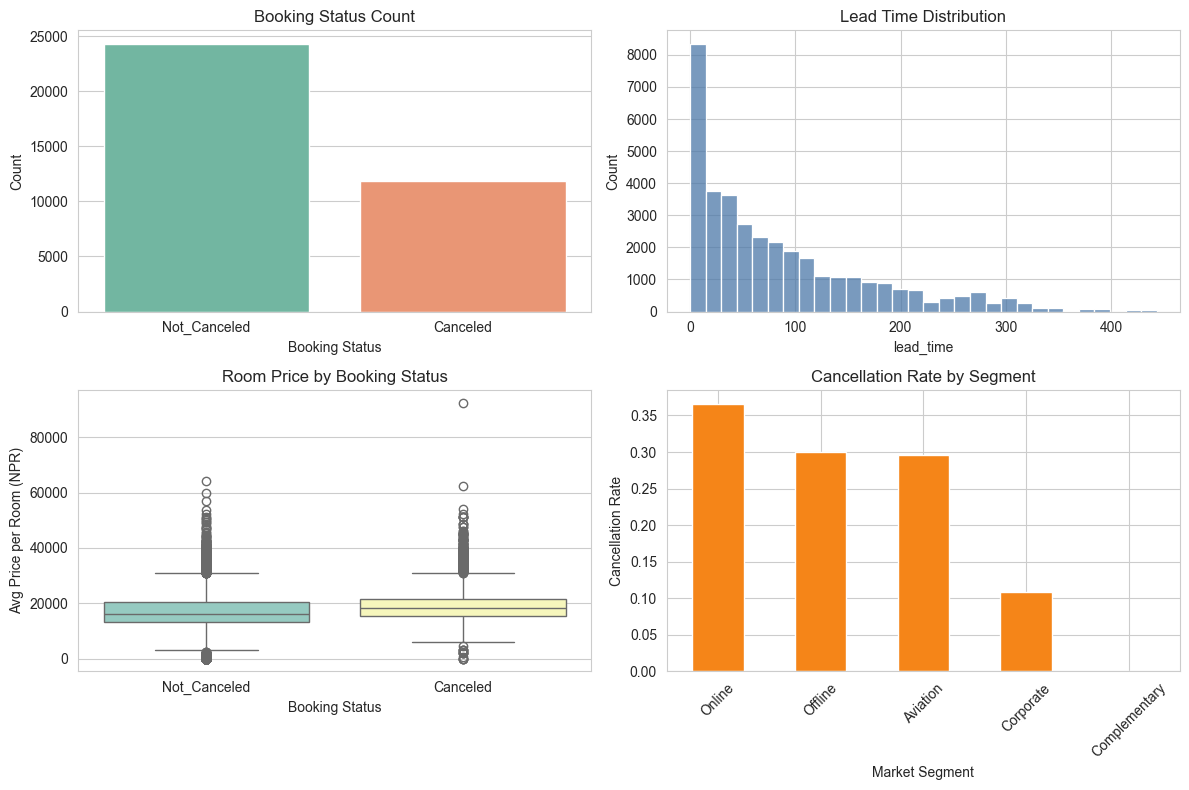

In [5]:
print("Booking status distribution:")
print(data["booking_status"].value_counts())

segment_cancel_rate = (
    data.groupby("market_segment_type")["cancellation"].mean()
    .sort_values(ascending=False)
)
print("\nCancellation rate by market segment:")
print(segment_cancel_rate.round(3))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

sns.countplot(data=data, x="booking_status", ax=ax[0, 0], palette="Set2")
ax[0, 0].set_title("Booking Status Count")
ax[0, 0].set_xlabel("Booking Status")
ax[0, 0].set_ylabel("Count")

sns.histplot(data=data, x="lead_time", bins=30, color="#4C78A8", ax=ax[0, 1])
ax[0, 1].set_title("Lead Time Distribution")

sns.boxplot(data=data, x="booking_status", y="avg_price_per_room", ax=ax[1, 0], palette="Set3")
ax[1, 0].set_title("Room Price by Booking Status")
ax[1, 0].set_xlabel("Booking Status")
ax[1, 0].set_ylabel("Avg Price per Room (NPR)")

segment_cancel_rate.plot(kind="bar", color="#F58518", ax=ax[1, 1])
ax[1, 1].set_title("Cancellation Rate by Segment")
ax[1, 1].set_xlabel("Market Segment")
ax[1, 1].set_ylabel("Cancellation Rate")
ax[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [6]:
# features I am using (same order as app)
selected_features = [
    "lead_time",
    "no_of_special_requests",
    "avg_price_per_room",
    "market_segment_type_encoded",
    "repeated_guest",
    "total_stays",
    "no_of_week_nights",
    "total_guests",
    "required_car_parking_space",
    "no_of_weekend_nights",
    "no_of_previous_bookings_not_canceled",
]

X = data[selected_features].copy()
y = data["cancellation"].copy()

print("Features used:")
print(selected_features)
print("X shape:", X.shape)



Features used:
['lead_time', 'no_of_special_requests', 'avg_price_per_room', 'market_segment_type_encoded', 'repeated_guest', 'total_stays', 'no_of_week_nights', 'total_guests', 'required_car_parking_space', 'no_of_weekend_nights', 'no_of_previous_bookings_not_canceled']
X shape: (36194, 11)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)



X_train: (28955, 11)
X_test: (7239, 11)


Random split metrics (default cutoff = 0.50)
accuracy     0.882719
roc_auc      0.943563
precision    0.831524
recall       0.805976
f1           0.818551
dtype: object

Confusion Matrix
[[4475  388]
 [ 461 1915]]

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      4863
           1       0.83      0.81      0.82      2376

    accuracy                           0.88      7239
   macro avg       0.87      0.86      0.87      7239
weighted avg       0.88      0.88      0.88      7239



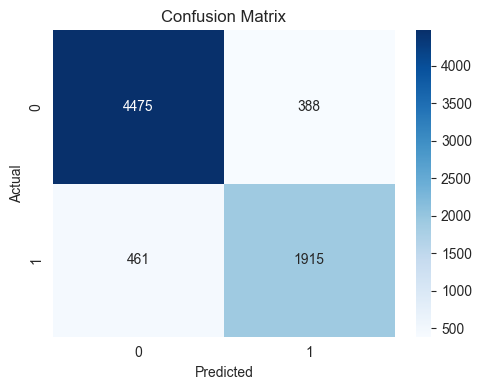

In [8]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
)

rf.fit(X_train, y_train)
y_prob = rf.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)


def evaluate_binary(y_true, y_prob):
    y_pred_local = (y_prob >= 0.5).astype(int)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred_local)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "precision": float(precision_score(y_true, y_pred_local, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred_local, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred_local, zero_division=0)),
        "confusion_matrix": confusion_matrix(y_true, y_pred_local).tolist(),
    }


random_metrics = evaluate_binary(y_test, y_prob)

print("Random split metrics (default cutoff = 0.50)")
print(pd.Series(random_metrics).drop("confusion_matrix"))
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()




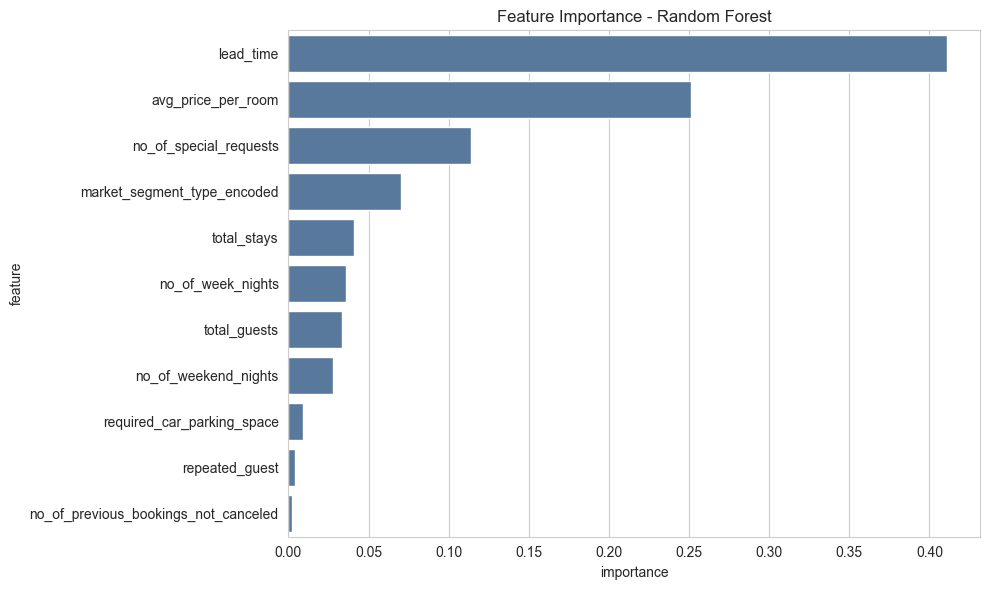

In [9]:
importance_df = (
    pd.DataFrame(
        {
            "feature": selected_features,
            "importance": rf.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="importance", y="feature", color="#4C78A8")
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.show()



In [10]:
os.makedirs("model_files", exist_ok=True)

# train final model on full data for app use
rf_final = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
)
rf_final.fit(X, y)

with open("model_files/random_forest_model.pkl", "wb") as f:
    pickle.dump(rf_final, f)

with open("model_files/encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

with open("model_files/feature_cols.pkl", "wb") as f:
    pickle.dump(selected_features, f)

importance_df.to_csv("model_files/feature_importance_full.csv", index=False)
pd.DataFrame({"feature": selected_features}).to_csv("model_files/selected_features.csv", index=False)

model_meta = {
    "model_version": f"rf_beginner_{datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S')}",
    "trained_at_utc": datetime.now(timezone.utc).isoformat(),
    "rows_used": int(len(data)),
    "feature_cols": selected_features,
    "metrics": {
        "random_split_default_cutoff_0_5": random_metrics,
    },
}

with open("model_files/model_meta.json", "w", encoding="utf-8") as f:
    json.dump(model_meta, f, indent=2)

sample_prob = float(rf_final.predict_proba(X.iloc[[0]])[0, 1])

summary = {
    "rows_used": int(len(data)),
    "features_used": selected_features,
    "random_auc": round(float(random_metrics["roc_auc"]), 4),
    "smoke_test_probability": round(sample_prob, 4),
}

print("Saved:")
print("- model_files/random_forest_model.pkl")
print("- model_files/encoders.pkl")
print("- model_files/feature_cols.pkl")
print("- model_files/feature_importance_full.csv")
print("- model_files/selected_features.csv")
print("- model_files/model_meta.json")

summary



Saved:
- model_files/random_forest_model.pkl
- model_files/encoders.pkl
- model_files/feature_cols.pkl
- model_files/feature_importance_full.csv
- model_files/selected_features.csv
- model_files/model_meta.json


{'rows_used': 36194,
 'features_used': ['lead_time',
  'no_of_special_requests',
  'avg_price_per_room',
  'market_segment_type_encoded',
  'repeated_guest',
  'total_stays',
  'no_of_week_nights',
  'total_guests',
  'required_car_parking_space',
  'no_of_weekend_nights',
  'no_of_previous_bookings_not_canceled'],
 'random_auc': 0.9436,
 'smoke_test_probability': 0.0}